# Predicción de horas con Hs ≥ 3 m y restricciones operativas en 2027

Este notebook estima, para Gijón Costera y Bilbao Costera, las **horas mensuales con altura significativa de ola igual o superior a 3 m** durante 2027. Posteriormente aplica las funciones históricas de regresión para obtener una estimación mensual de las horas de restricción operativa.

La predicción se valida de forma cronológica: los modelos se ajustan con 2005–2021 y se comparan con los valores realmente observados entre 2022 y 2024.

## 1. Importaciones

In [ ]:
import os
import glob
import calendar
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
from statsmodels.tsa.holtwinters import ExponentialSmoothing

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

## 2. Carga de los datos

Sube los tres CSV cuando Colab abra el selector. Si ya están en `/content`, la celda los detectará automáticamente.

In [ ]:
required_fragments = [
    'dataset_principal_oleaje',
    'trafico_portuario_gijon',
    'trafico_portuario_bilbao',
]

available = glob.glob('/content/*.csv')

if not all(any(fragment in Path(file).name.lower() for file in available)
           for fragment in required_fragments):
    from google.colab import files
    files.upload()
    available = glob.glob('/content/*.csv')

def find_csv(fragment):
    matches = [file for file in available if fragment in Path(file).name.lower()]
    if not matches:
        raise FileNotFoundError(f'No se encontró un archivo cuyo nombre contenga: {fragment}')
    return matches[0]

path_oleaje = find_csv('dataset_principal_oleaje')
path_gijon = find_csv('trafico_portuario_gijon')
path_bilbao = find_csv('trafico_portuario_bilbao')

print('Oleaje:', Path(path_oleaje).name)
print('Tráfico Gijón:', Path(path_gijon).name)
print('Tráfico Bilbao:', Path(path_bilbao).name)

Oleaje: dataset_principal_oleaje.csv
Tráfico Gijón: trafico_portuario_gijon_pes_revisado.csv
Tráfico Bilbao: trafico_portuario_bilbao_pes_revisado.csv


In [ ]:
oleaje = pd.read_csv(path_oleaje, parse_dates=['fecha'])
trafico_gijon = pd.read_csv(path_gijon)
trafico_bilbao = pd.read_csv(path_bilbao)

for tabla in (trafico_gijon, trafico_bilbao):
    tabla['mes'] = pd.to_datetime(tabla['mes'].astype(str).str[:7] + '-01')

print('Registros horarios de oleaje:', len(oleaje))
display(oleaje.groupby(['codigo_boya', 'nombre_boya']).agg(
    inicio=('fecha', 'min'),
    fin=('fecha', 'max'),
    registros=('Hs_m', 'size')
).reset_index())

print('Columnas del tráfico de Gijón:', list(trafico_gijon.columns))
print('Columnas del tráfico de Bilbao:', list(trafico_bilbao.columns))

Registros horarios de oleaje: 610438


,codigo_boya,nombre_boya,inicio,fin,registros
0,1103,Bilbao costera,2005-01-01 00:00:00,2024-12-31 23:00:00,140991
1,1117,Gijón costera,2005-01-05 09:00:00,2024-12-31 23:00:00,150719
2,2136,Bilbao-Vizcaya,2005-01-01 00:00:00,2024-12-31 23:00:00,162793
3,2242,Cabo de Peñas,2004-12-31 00:00:00,2024-12-31 23:00:00,155935


Columnas del tráfico de Gijón: ['mes', 'puerto', 'horas_restriccion', 'granel_solido_t', 'granel_liquido_t', 'mercancia_general_t', 'contenedores_teu', 'escalas_buque']
Columnas del tráfico de Bilbao: ['mes', 'puerto', 'horas_restriccion', 'granel_solido_t', 'granel_liquido_t', 'mercancia_general_t', 'contenedores_teu', 'escalas_buque']


## 3. Construcción de la serie mensual objetivo

Cada valor representa las horas del mes con `Hs_m >= 3`. Solo se consideran válidos los meses cuya cobertura de observaciones de Hs alcanza el 70 % de sus horas teóricas.

In [ ]:
COBERTURA_MINIMA = 0.70

def construir_serie_hs3(df_oleaje, codigo_boya, cobertura_minima=COBERTURA_MINIMA):
    datos = df_oleaje.loc[
        (df_oleaje['codigo_boya'].eq(codigo_boya)) & df_oleaje['Hs_m'].notna(),
        ['fecha', 'Hs_m']
    ].copy()
    datos['mes'] = datos['fecha'].dt.to_period('M').dt.to_timestamp()
    datos['hs_ge_3m'] = datos['Hs_m'].ge(3)

    mensual = (datos.groupby('mes', as_index=False)
        .agg(
            horas_hs_ge_3m=('hs_ge_3m', 'sum'),
            horas_observadas=('Hs_m', 'size')
        ))

    indice_completo = pd.date_range('2005-01-01', '2024-12-01', freq='MS')
    mensual = mensual.set_index('mes').reindex(indice_completo).rename_axis('mes').reset_index()
    mensual['horas_teoricas'] = mensual['mes'].apply(
        lambda fecha: calendar.monthrange(fecha.year, fecha.month)[1] * 24
    )
    mensual['cobertura'] = mensual['horas_observadas'] / mensual['horas_teoricas']
    mensual['mes_valido'] = mensual['cobertura'].ge(cobertura_minima)
    mensual.loc[~mensual['mes_valido'], 'horas_hs_ge_3m'] = np.nan
    return mensual

serie_gijon = construir_serie_hs3(oleaje, 1117)
serie_bilbao = construir_serie_hs3(oleaje, 1103)

series_hs3 = {'Gijón': serie_gijon, 'Bilbao': serie_bilbao}

for puerto, serie in series_hs3.items():
    print(f'{puerto}: {serie.mes_valido.sum()} meses válidos de {len(serie)}')
    display(serie.head())

Gijón: 202 meses válidos de 240


,mes,horas_hs_ge_3m,horas_observadas,horas_teoricas,cobertura,mes_valido
0,2005-01-01,164.000,528.000,744,0.710,True
1,2005-02-01,NaN,252.000,672,0.375,False
2,2005-03-01,11.000,737.000,744,0.991,True
3,2005-04-01,56.000,718.000,720,0.997,True
4,2005-05-01,0.000,739.000,744,0.993,True


Bilbao: 185 meses válidos de 240


,mes,horas_hs_ge_3m,horas_observadas,horas_teoricas,cobertura,mes_valido
0,2005-01-01,NaN,249.000,744,0.335,False
1,2005-02-01,53.000,608.000,672,0.905,True
2,2005-03-01,5.000,735.000,744,0.988,True
3,2005-04-01,44.000,701.000,720,0.974,True
4,2005-05-01,0.000,730.000,744,0.981,True


## 4. Preparación y validación temporal

Se ajustan los modelos con 2005–2021 y se validan con 2022–2024. Los meses sin cobertura suficiente no se usan para calcular los errores. Para que Holt-Winters pueda ajustarse, los huecos del entrenamiento se completan con la mediana histórica del mismo mes, calculada únicamente con los datos de entrenamiento.

In [ ]:
INICIO_ENTRENAMIENTO = '2005-01-01'
FIN_ENTRENAMIENTO = '2021-12-01'
INICIO_VALIDACION = '2022-01-01'
FIN_VALIDACION = '2024-12-01'

def completar_entrenamiento(serie, inicio, fin):
    datos = (serie.loc[(serie['mes'] >= inicio) & (serie['mes'] <= fin),
                         ['mes', 'horas_hs_ge_3m']]
             .set_index('mes')
             .asfreq('MS'))
    valores = datos['horas_hs_ge_3m'].astype(float).copy()
    medianas_mes = valores.groupby(valores.index.month).median()
    mediana_global = valores.median()
    for fecha in valores.index[valores.isna()]:
        reemplazo = medianas_mes.get(fecha.month, mediana_global)
        valores.loc[fecha] = mediana_global if pd.isna(reemplazo) else reemplazo
    return valores

def horas_teoricas_indice(indice):
    return np.array([calendar.monthrange(fecha.year, fecha.month)[1] * 24 for fecha in indice])

def predecir_ingenuo_estacional(serie_entrenamiento, pasos):
    patron = serie_entrenamiento.iloc[-12:].to_numpy()
    prediccion = np.resize(patron, pasos)
    indice = pd.date_range(serie_entrenamiento.index[-1] + pd.offsets.MonthBegin(1),
                           periods=pasos, freq='MS')
    return pd.Series(prediccion, index=indice, name='Ingenuo estacional')

def predecir_holt_winters(serie_entrenamiento, pasos):
    modelo = ExponentialSmoothing(
        serie_entrenamiento,
        trend='add',
        damped_trend=True,
        seasonal='add',
        seasonal_periods=12,
        initialization_method='estimated'
    ).fit(optimized=True, use_brute=True)
    prediccion = modelo.forecast(pasos)
    prediccion.name = 'Holt-Winters'
    return prediccion

def limitar_horas(prediccion):
    limites = horas_teoricas_indice(prediccion.index)
    valores = np.clip(prediccion.to_numpy(dtype=float), 0, limites)
    return pd.Series(valores, index=prediccion.index, name=prediccion.name)


In [ ]:
def validar_modelos(serie, puerto):
    entrenamiento = completar_entrenamiento(serie, INICIO_ENTRENAMIENTO, FIN_ENTRENAMIENTO)
    pasos = 36

    pred_ingenuo = limitar_horas(predecir_ingenuo_estacional(entrenamiento, pasos))
    pred_holt = limitar_horas(predecir_holt_winters(entrenamiento, pasos))

    observados = (serie.set_index('mes')['horas_hs_ge_3m']
        .reindex(pd.date_range(INICIO_VALIDACION, FIN_VALIDACION, freq='MS')))
    validos = observados.notna()

    filas = []
    for nombre, prediccion in [('Ingenuo estacional', pred_ingenuo), ('Holt-Winters', pred_holt)]:
        y_real = observados.loc[validos]
        y_pred = prediccion.loc[validos]
        filas.append({
            'Puerto': puerto,
            'Modelo': nombre,
            'Meses válidos evaluados': int(validos.sum()),
            'MAE (h)': mean_absolute_error(y_real, y_pred),
            'RMSE (h)': np.sqrt(mean_squared_error(y_real, y_pred))
        })

    detalle = pd.DataFrame({
        'horas_observadas': observados,
        'ingenuo_estacional': pred_ingenuo,
        'holt_winters': pred_holt,
        'mes_valido_para_evaluacion': validos
    }).reset_index(names='mes')
    return pd.DataFrame(filas), detalle

resultados_validacion = []
detalles_validacion = {}

for puerto, serie in series_hs3.items():
    resumen, detalle = validar_modelos(serie, puerto)
    resultados_validacion.append(resumen)
    detalles_validacion[puerto] = detalle

resultados_validacion = pd.concat(resultados_validacion, ignore_index=True)
display(resultados_validacion.sort_values(['Puerto', 'MAE (h)']))

modelos_elegidos = (resultados_validacion
    .sort_values(['Puerto', 'MAE (h)'])
    .groupby('Puerto', as_index=False)
    .first()[['Puerto', 'Modelo', 'MAE (h)', 'RMSE (h)']])

print('Modelo seleccionado para cada puerto:')
display(modelos_elegidos)

,Puerto,Modelo,Meses válidos evaluados,MAE (h),RMSE (h)
3,Bilbao,Holt-Winters,20,24.907,34.819
2,Bilbao,Ingenuo estacional,20,31.150,45.640
1,Gijón,Holt-Winters,36,33.376,48.776
0,Gijón,Ingenuo estacional,36,35.500,58.909


Modelo seleccionado para cada puerto:


,Puerto,Modelo,MAE (h),RMSE (h)
0,Bilbao,Holt-Winters,24.907,34.819
1,Gijón,Holt-Winters,33.376,48.776


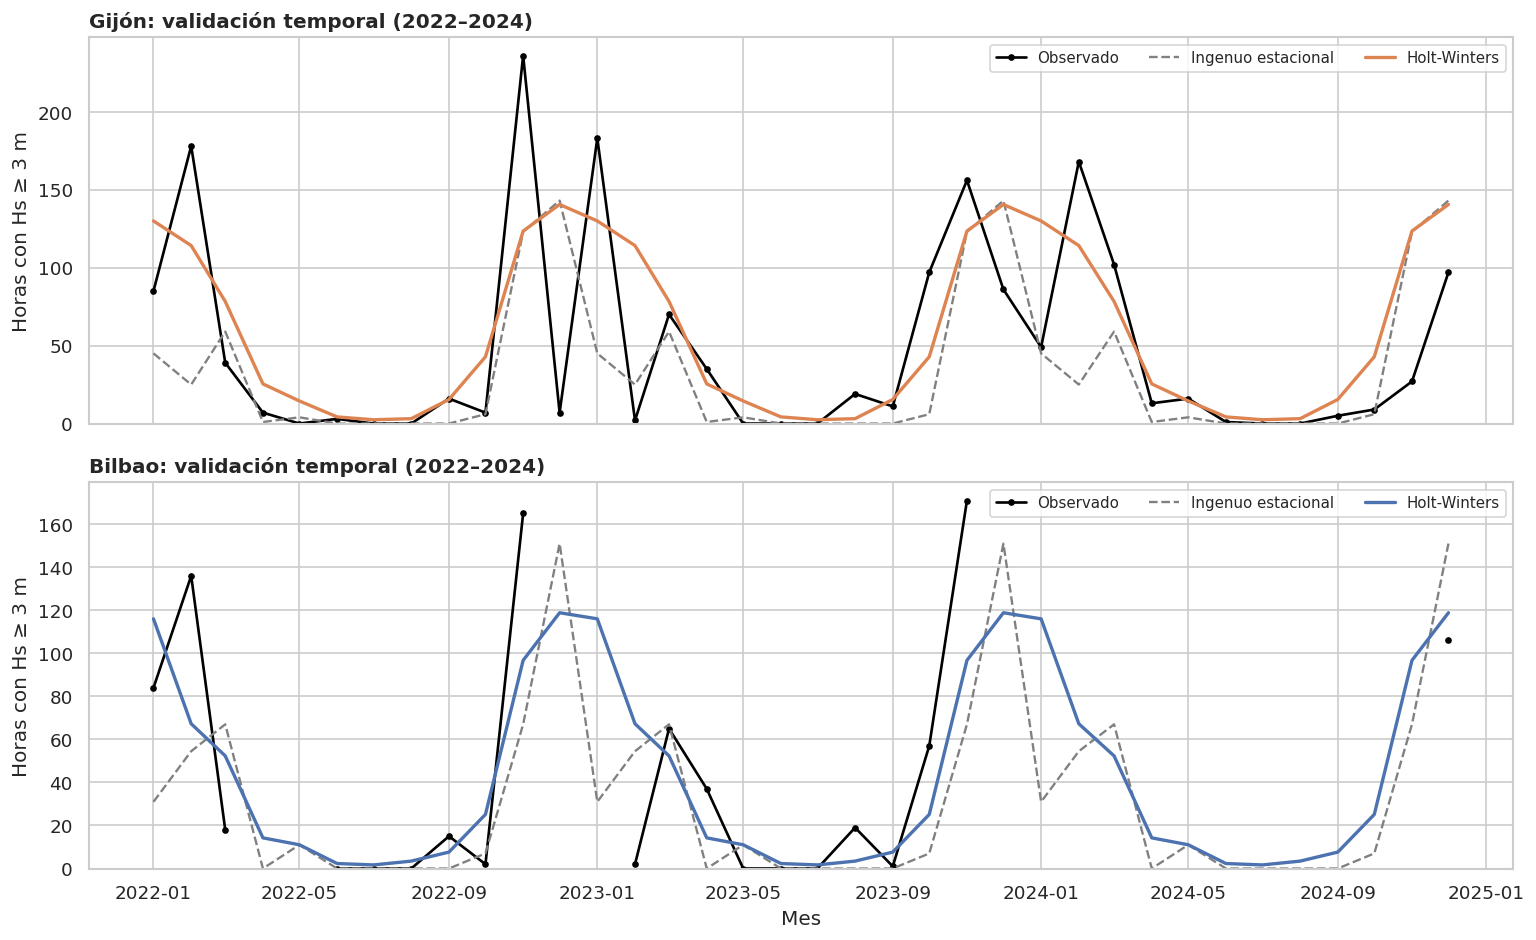

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
colores = {'Gijón': '#DD8452', 'Bilbao': '#4C72B0'}

for ax, puerto in zip(axes, ['Gijón', 'Bilbao']):
    datos = detalles_validacion[puerto]
    ax.plot(datos['mes'], datos['horas_observadas'], color='black', marker='o',
            linewidth=1.6, markersize=3, label='Observado')
    ax.plot(datos['mes'], datos['ingenuo_estacional'], color='#808080', linestyle='--',
            linewidth=1.4, label='Ingenuo estacional')
    ax.plot(datos['mes'], datos['holt_winters'], color=colores[puerto],
            linewidth=2, label='Holt-Winters')
    ax.set_title(f'{puerto}: validación temporal (2022–2024)', loc='left', fontweight='bold')
    ax.set_ylabel('Horas con Hs ≥ 3 m')
    ax.set_ylim(bottom=0)
    ax.legend(ncol=3, fontsize=9)

axes[-1].set_xlabel('Mes')
plt.tight_layout()
plt.show()

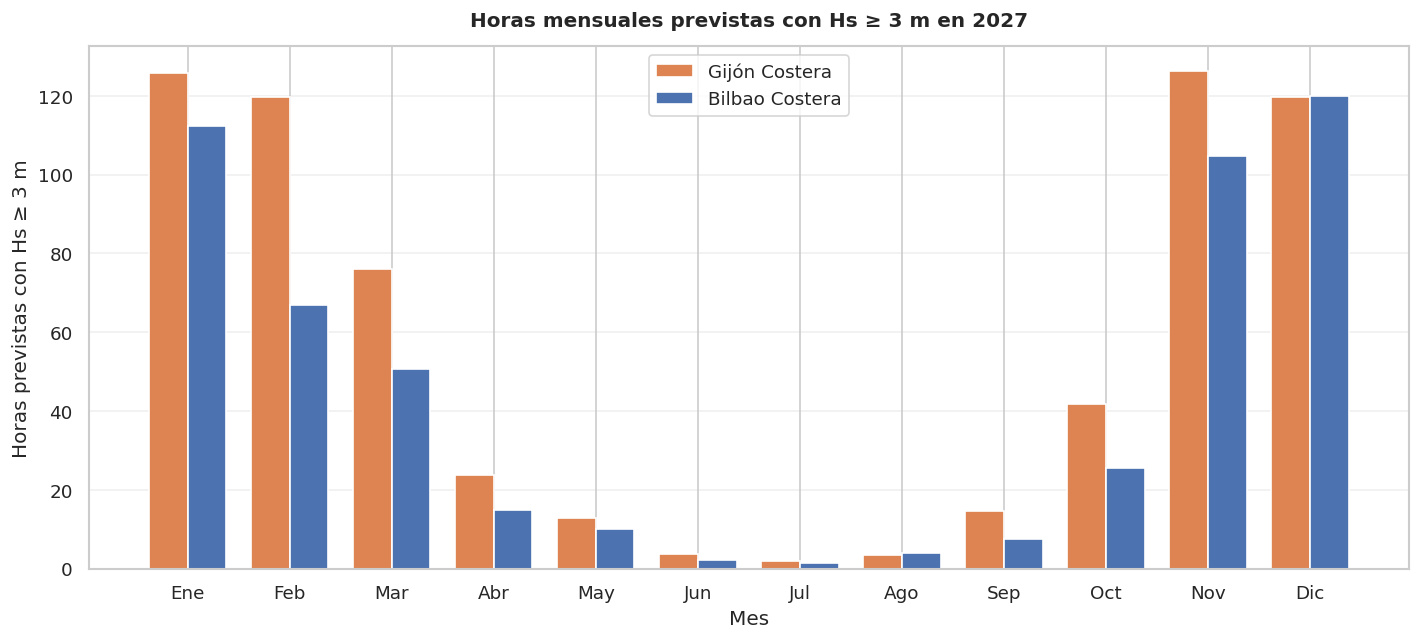

In [ ]:
# GRÁFICO: horas previstas con Hs ≥ 3 m únicamente en 2027

import numpy as np
import matplotlib.pyplot as plt

meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

x = np.arange(12)
ancho = 0.38

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.bar(
    x - ancho / 2,
    tabla_hs3_2027['horas_hs_ge_3m_previstas_gijon'],
    width=ancho,
    color='#DD8452',
    label='Gijón Costera'
)

ax.bar(
    x + ancho / 2,
    tabla_hs3_2027['horas_hs_ge_3m_previstas_bilbao'],
    width=ancho,
    color='#4C72B0',
    label='Bilbao Costera'
)

ax.set_title(
    'Horas mensuales previstas con Hs ≥ 3 m en 2027',
    fontweight='bold',
    pad=12
)
ax.set_xlabel('Mes')
ax.set_ylabel('Horas previstas con Hs ≥ 3 m')
ax.set_xticks(x)
ax.set_xticklabels(meses)
ax.set_ylim(bottom=0)
ax.legend(frameon=True)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Predicción final para 2027

Se reajusta el modelo elegido con todos los datos disponibles entre 2005 y 2024. Se predicen 36 meses desde enero de 2025; posteriormente se conservan los doce meses de 2027.

In [ ]:
def predecir_2027(serie, modelo_elegido):
    entrenamiento_completo = completar_entrenamiento(serie, '2005-01-01', '2024-12-01')
    pasos = 36

    if modelo_elegido == 'Holt-Winters':
        prediccion = predecir_holt_winters(entrenamiento_completo, pasos)
    else:
        prediccion = predecir_ingenuo_estacional(entrenamiento_completo, pasos)

    prediccion = limitar_horas(prediccion)
    return prediccion

predicciones_completas = {}
predicciones_2027 = {}

for puerto, serie in series_hs3.items():
    modelo = modelos_elegidos.loc[modelos_elegidos['Puerto'].eq(puerto), 'Modelo'].iloc[0]
    prediccion = predecir_2027(serie, modelo)
    predicciones_completas[puerto] = prediccion
    predicciones_2027[puerto] = prediccion.loc['2027-01-01':'2027-12-01']

tabla_hs3_2027 = pd.DataFrame({
    'mes': predicciones_2027['Gijón'].index,
    'horas_hs_ge_3m_previstas_gijon': predicciones_2027['Gijón'].values,
    'horas_hs_ge_3m_previstas_bilbao': predicciones_2027['Bilbao'].values
})
tabla_hs3_2027['horas_teoricas_mes'] = tabla_hs3_2027['mes'].apply(
    lambda fecha: calendar.monthrange(fecha.year, fecha.month)[1] * 24
)
tabla_hs3_2027['porcentaje_hs_ge_3m_gijon'] = (
    100 * tabla_hs3_2027['horas_hs_ge_3m_previstas_gijon'] / tabla_hs3_2027['horas_teoricas_mes']
)
tabla_hs3_2027['porcentaje_hs_ge_3m_bilbao'] = (
    100 * tabla_hs3_2027['horas_hs_ge_3m_previstas_bilbao'] / tabla_hs3_2027['horas_teoricas_mes']
)

display(tabla_hs3_2027.round(2))

,mes,horas_hs_ge_3m_previstas_gijon,horas_hs_ge_3m_previstas_bilbao,horas_teoricas_mes,porcentaje_hs_ge_3m_gijon,porcentaje_hs_ge_3m_bilbao
0,2027-01-01,125.840,112.320,744,16.910,15.100
1,2027-02-01,119.680,66.830,672,17.810,9.940
2,2027-03-01,75.930,50.600,744,10.210,6.800
3,2027-04-01,23.740,14.830,720,3.300,2.060
4,2027-05-01,12.830,10.060,744,1.720,1.350
5,2027-06-01,3.670,2.060,720,0.510,0.290
6,2027-07-01,1.940,1.510,744,0.260,0.200
7,2027-08-01,3.520,3.970,744,0.470,0.530
8,2027-09-01,14.580,7.580,720,2.020,1.050
9,2027-10-01,41.790,25.450,744,5.620,3.420


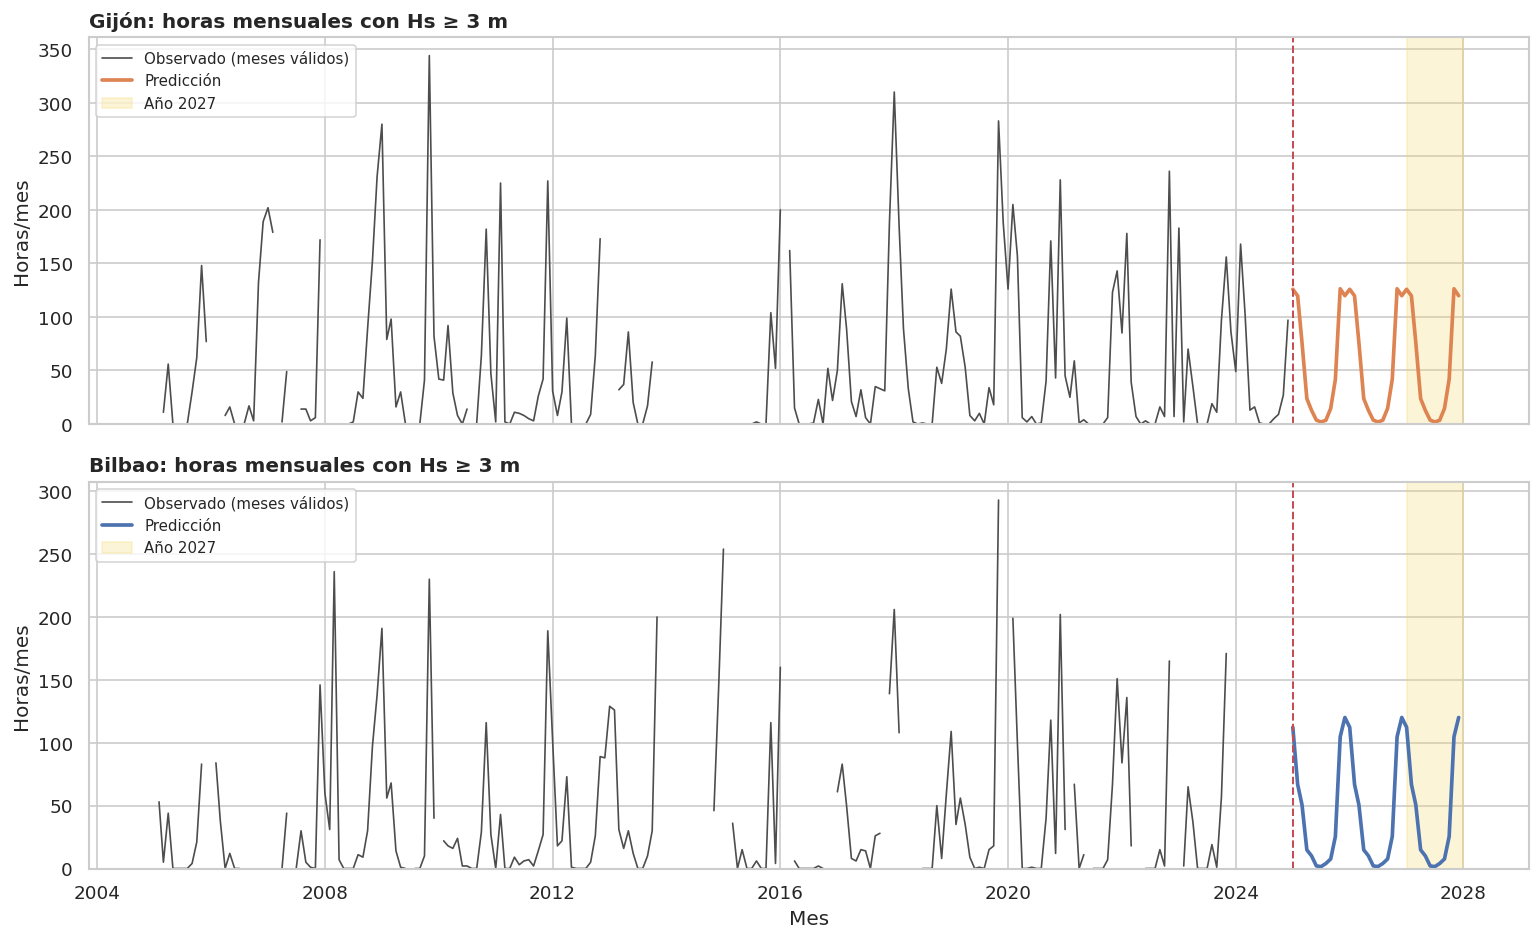

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
colores = {'Gijón': '#DD8452', 'Bilbao': '#4C72B0'}

for ax, puerto in zip(axes, ['Gijón', 'Bilbao']):
    observada = series_hs3[puerto].set_index('mes')['horas_hs_ge_3m']
    futura = predicciones_completas[puerto]
    ax.plot(observada.index, observada.values, color='#4D4D4D', linewidth=1.0,
            label='Observado (meses válidos)')
    ax.plot(futura.index, futura.values, color=colores[puerto], linewidth=2.2,
            label='Predicción')
    ax.axvline(pd.Timestamp('2025-01-01'), color='#C44E52', linestyle='--', linewidth=1.2)
    ax.axvspan(pd.Timestamp('2027-01-01'), pd.Timestamp('2027-12-31'),
               color='#F6D55C', alpha=0.25, label='Año 2027')
    ax.set_title(f'{puerto}: horas mensuales con Hs ≥ 3 m', loc='left', fontweight='bold')
    ax.set_ylabel('Horas/mes')
    ax.set_ylim(bottom=0)
    ax.legend(loc='upper left', fontsize=9)

axes[-1].set_xlabel('Mes')
plt.tight_layout()
plt.show()

## 6. Ajuste reproducible de las funciones de restricciones

Las funciones se ajustan de nuevo con todos los meses válidos de 2005–2024. De este modo, la aplicación a 2027 queda completamente reproducible dentro de este notebook.

In [ ]:
def ajustar_funcion_restricciones(serie_hs3, trafico, puerto):
    restricciones = trafico[['mes', 'horas_restriccion']].copy()
    pares = (serie_hs3[['mes', 'horas_hs_ge_3m', 'mes_valido']]
        .merge(restricciones, on='mes', how='inner')
        .query('mes_valido')
        .dropna(subset=['horas_hs_ge_3m', 'horas_restriccion'])
        .sort_values('mes'))

    X = pares[['horas_hs_ge_3m']]
    y = pares['horas_restriccion']
    modelo = LinearRegression().fit(X, y)
    pendiente, _, _, p_valor, _ = stats.linregress(pares['horas_hs_ge_3m'], y)

    return pares, {
        'Puerto': puerto,
        'alfa': modelo.intercept_,
        'beta': modelo.coef_[0],
        'R2': r2_score(y, modelo.predict(X)),
        'RMSE_h': np.sqrt(mean_squared_error(y, modelo.predict(X))),
        'MAE_h': mean_absolute_error(y, modelo.predict(X)),
        'p_valor_beta': p_valor,
        'n_meses_validos': len(pares)
    }

pares_gijon, funcion_gijon = ajustar_funcion_restricciones(serie_gijon, trafico_gijon, 'Gijón')
pares_bilbao, funcion_bilbao = ajustar_funcion_restricciones(serie_bilbao, trafico_bilbao, 'Bilbao')

tabla_funciones = pd.DataFrame([funcion_gijon, funcion_bilbao])
tabla_funciones['funcion_estimada'] = tabla_funciones.apply(
    lambda fila: f"R = {fila['alfa']:.3f} + ({fila['beta']:.3f} × H3m)", axis=1
)

display(tabla_funciones[[
    'Puerto', 'funcion_estimada', 'R2', 'RMSE_h', 'MAE_h', 'p_valor_beta', 'n_meses_validos'
]].round(3))

,Puerto,funcion_estimada,R2,RMSE_h,MAE_h,p_valor_beta,n_meses_validos
0,Gijón,R = 2.518 + (0.061 × H3m),0.467,4.753,3.902,0.000,202
1,Bilbao,R = 1.532 + (0.049 × H3m),0.373,3.782,2.842,0.000,185


## 7. Restricciones operativas estimadas para 2027

In [ ]:
alfa_gijon, beta_gijon = funcion_gijon['alfa'], funcion_gijon['beta']
alfa_bilbao, beta_bilbao = funcion_bilbao['alfa'], funcion_bilbao['beta']

tabla_resultados_2027 = tabla_hs3_2027.copy()
tabla_resultados_2027['restricciones_estimadas_gijon_h'] = (
    alfa_gijon + beta_gijon * tabla_resultados_2027['horas_hs_ge_3m_previstas_gijon']
)
tabla_resultados_2027['restricciones_estimadas_bilbao_h'] = (
    alfa_bilbao + beta_bilbao * tabla_resultados_2027['horas_hs_ge_3m_previstas_bilbao']
)

nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                  'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
tabla_resultados_2027['mes_nombre'] = tabla_resultados_2027['mes'].dt.month.map(
    dict(enumerate(nombres_meses, start=1))
)
tabla_resultados_2027 = tabla_resultados_2027[[
    'mes', 'mes_nombre', 'horas_hs_ge_3m_previstas_gijon', 'porcentaje_hs_ge_3m_gijon',
    'restricciones_estimadas_gijon_h', 'horas_hs_ge_3m_previstas_bilbao',
    'porcentaje_hs_ge_3m_bilbao', 'restricciones_estimadas_bilbao_h'
]]

print('Resultados mensuales estimados para 2027:')
display(tabla_resultados_2027.round(2))

print('Totales anuales estimados:')
display(pd.DataFrame([{
    'Puerto': 'Gijón',
    'Horas Hs ≥ 3 m estimadas': tabla_resultados_2027['horas_hs_ge_3m_previstas_gijon'].sum(),
    'Restricciones estimadas (h)': tabla_resultados_2027['restricciones_estimadas_gijon_h'].sum()
}, {
    'Puerto': 'Bilbao',
    'Horas Hs ≥ 3 m estimadas': tabla_resultados_2027['horas_hs_ge_3m_previstas_bilbao'].sum(),
    'Restricciones estimadas (h)': tabla_resultados_2027['restricciones_estimadas_bilbao_h'].sum()
}]).round(2))

Resultados mensuales estimados para 2027:


,mes,mes_nombre,horas_hs_ge_3m_previstas_gijon,porcentaje_hs_ge_3m_gijon,restricciones_estimadas_gijon_h,horas_hs_ge_3m_previstas_bilbao,porcentaje_hs_ge_3m_bilbao,restricciones_estimadas_bilbao_h
0,2027-01-01,Enero,125.840,16.910,10.250,112.320,15.100,7.000
1,2027-02-01,Febrero,119.680,17.810,9.870,66.830,9.940,4.780
2,2027-03-01,Marzo,75.930,10.210,7.180,50.600,6.800,3.990
3,2027-04-01,Abril,23.740,3.300,3.980,14.830,2.060,2.250
4,2027-05-01,Mayo,12.830,1.720,3.310,10.060,1.350,2.020
5,2027-06-01,Junio,3.670,0.510,2.740,2.060,0.290,1.630
6,2027-07-01,Julio,1.940,0.260,2.640,1.510,0.200,1.610
7,2027-08-01,Agosto,3.520,0.470,2.730,3.970,0.530,1.730
8,2027-09-01,Septiembre,14.580,2.020,3.410,7.580,1.050,1.900
9,2027-10-01,Octubre,41.790,5.620,5.090,25.450,3.420,2.770


Totales anuales estimados:


,Puerto,Horas Hs ≥ 3 m estimadas,Restricciones estimadas (h)
0,Gijón,669.660,71.360
1,Bilbao,520.090,43.690


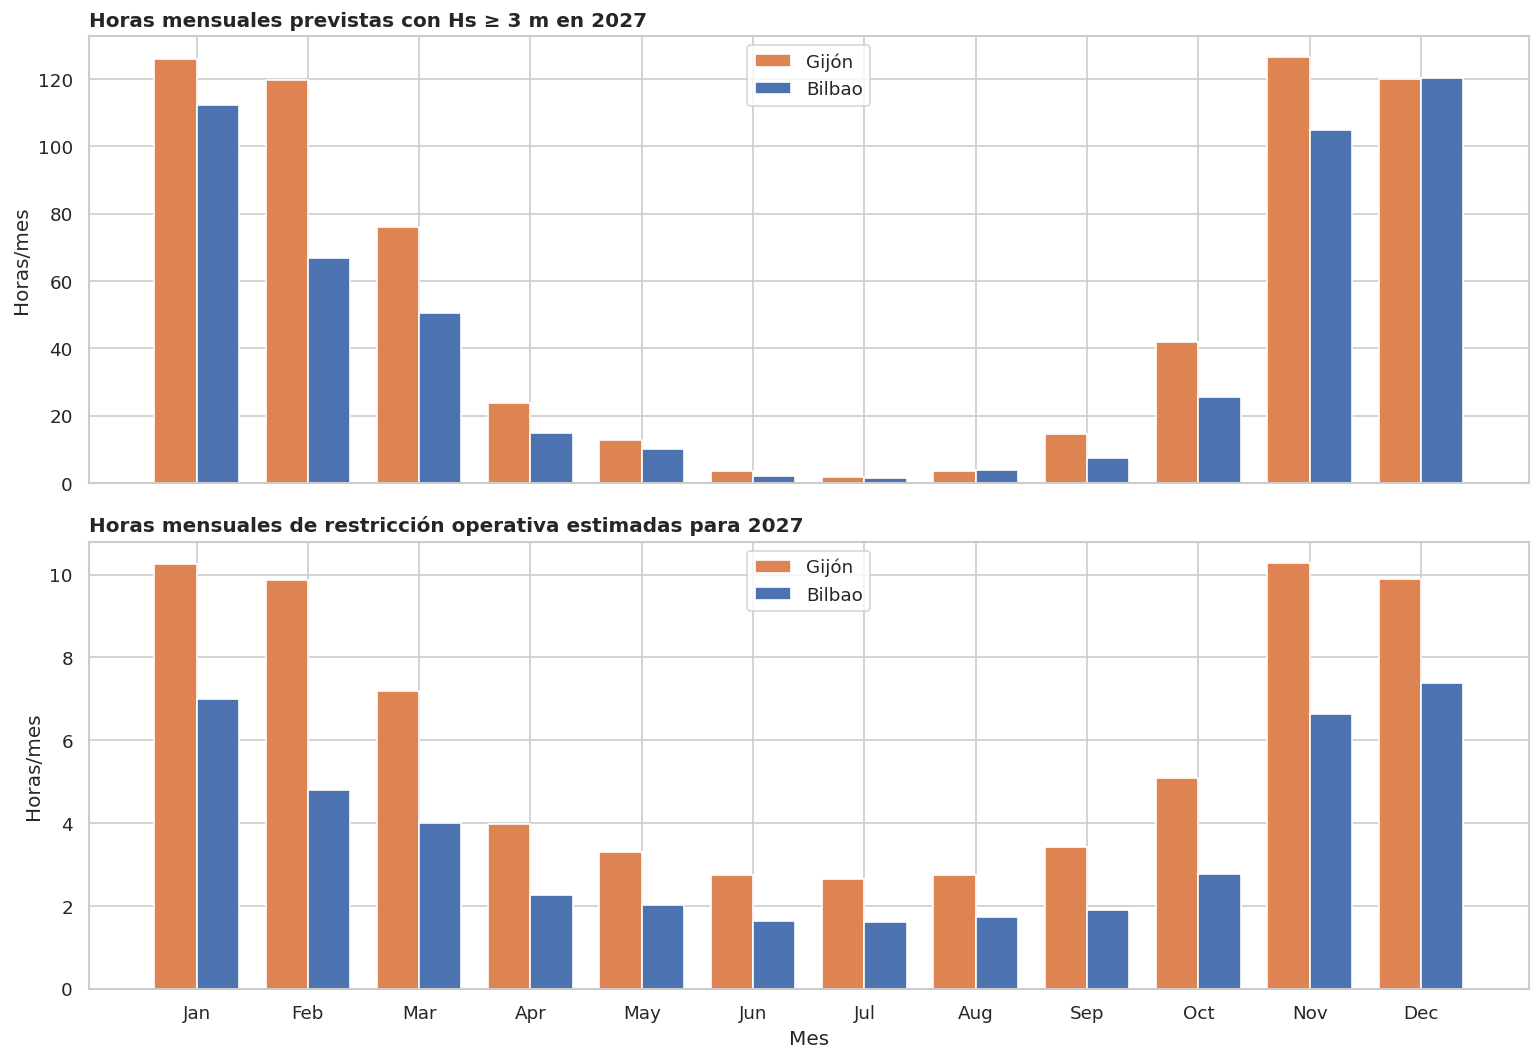

In [ ]:
meses = tabla_resultados_2027['mes'].dt.strftime('%b').str.capitalize()
x = np.arange(len(meses))
ancho = 0.38

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

axes[0].bar(x - ancho / 2, tabla_resultados_2027['horas_hs_ge_3m_previstas_gijon'],
            width=ancho, color='#DD8452', label='Gijón')
axes[0].bar(x + ancho / 2, tabla_resultados_2027['horas_hs_ge_3m_previstas_bilbao'],
            width=ancho, color='#4C72B0', label='Bilbao')
axes[0].set_title('Horas mensuales previstas con Hs ≥ 3 m en 2027', loc='left', fontweight='bold')
axes[0].set_ylabel('Horas/mes')
axes[0].legend()

axes[1].bar(x - ancho / 2, tabla_resultados_2027['restricciones_estimadas_gijon_h'],
            width=ancho, color='#DD8452', label='Gijón')
axes[1].bar(x + ancho / 2, tabla_resultados_2027['restricciones_estimadas_bilbao_h'],
            width=ancho, color='#4C72B0', label='Bilbao')
axes[1].set_title('Horas mensuales de restricción operativa estimadas para 2027',
                  loc='left', fontweight='bold')
axes[1].set_ylabel('Horas/mes')
axes[1].set_xlabel('Mes')
axes[1].legend()

axes[1].set_xticks(x)
axes[1].set_xticklabels(meses)
plt.tight_layout()
plt.show()

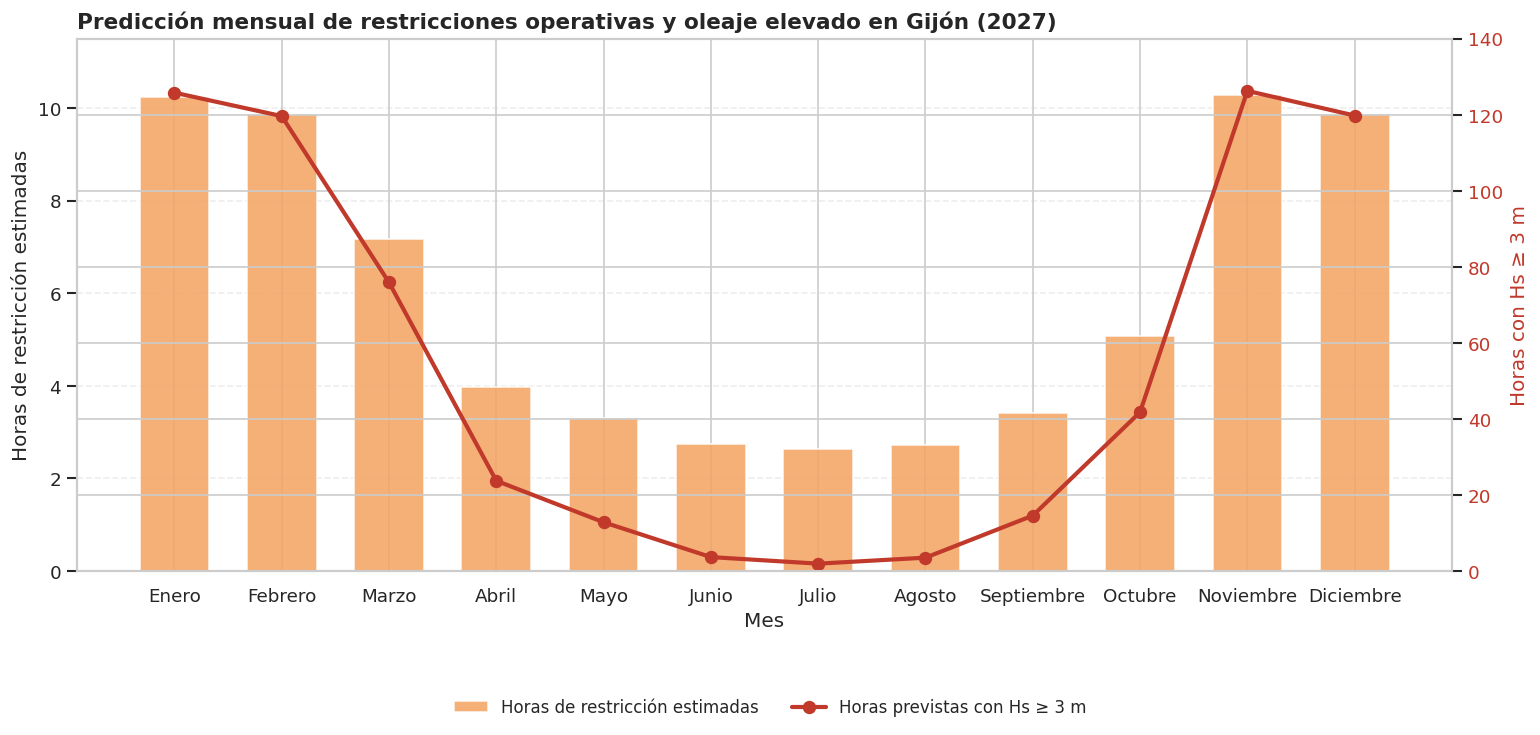

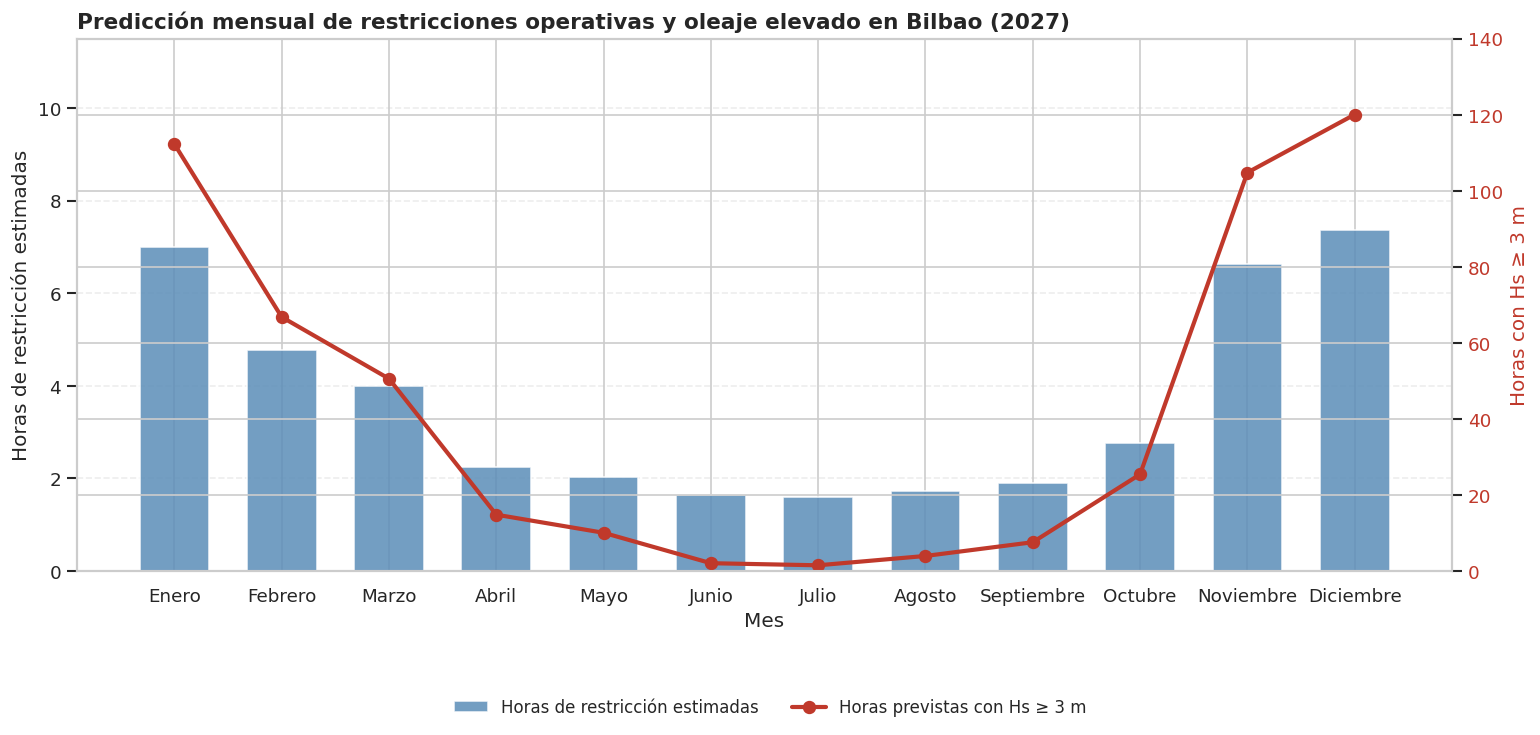

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

meses = tabla_resultados_2027['mes_nombre']
x = np.arange(len(meses))

# Límites comunes para que los dos gráficos sean comparables
max_restricciones = max(
    tabla_resultados_2027['restricciones_estimadas_gijon_h'].max(),
    tabla_resultados_2027['restricciones_estimadas_bilbao_h'].max()
)

max_hs3 = max(
    tabla_resultados_2027['horas_hs_ge_3m_previstas_gijon'].max(),
    tabla_resultados_2027['horas_hs_ge_3m_previstas_bilbao'].max()
)

# Margen superior y redondeo para una lectura más limpia
limite_restricciones = np.ceil((max_restricciones * 1.10) * 2) / 2
limite_hs3 = np.ceil((max_hs3 * 1.10) / 10) * 10

config_graficos = [
    {
        'puerto': 'Gijón',
        'col_restricciones': 'restricciones_estimadas_gijon_h',
        'col_hs3': 'horas_hs_ge_3m_previstas_gijon',
        'color_barras': '#F4A261'
    },
    {
        'puerto': 'Bilbao',
        'col_restricciones': 'restricciones_estimadas_bilbao_h',
        'col_hs3': 'horas_hs_ge_3m_previstas_bilbao',
        'color_barras': '#5B8DB8'
    }
]

for cfg in config_graficos:
    fig, ax1 = plt.subplots(figsize=(13, 6))

    # Barras: restricciones estimadas
    barras = ax1.bar(
        x,
        tabla_resultados_2027[cfg['col_restricciones']],
        width=0.65,
        color=cfg['color_barras'],
        alpha=0.85,
        label='Horas de restricción estimadas'
    )

    ax1.set_xlabel('Mes')
    ax1.set_ylabel('Horas de restricción estimadas')
    ax1.set_xticks(x)
    ax1.set_xticklabels(meses)
    ax1.set_ylim(0, limite_restricciones)
    ax1.grid(axis='y', linestyle='--', alpha=0.35)

    # Línea roja: horas previstas con Hs ≥ 3 m
    ax2 = ax1.twinx()

    linea = ax2.plot(
        x,
        tabla_resultados_2027[cfg['col_hs3']],
        color='#C0392B',
        marker='o',
        linewidth=2.5,
        markersize=7,
        label='Horas previstas con Hs ≥ 3 m'
    )

    ax2.set_ylabel('Horas con Hs ≥ 3 m', color='#C0392B')
    ax2.tick_params(axis='y', labelcolor='#C0392B')
    ax2.set_ylim(0, limite_hs3)

    ax1.set_title(
        f'Predicción mensual de restricciones operativas y oleaje elevado en {cfg["puerto"]} (2027)',
        loc='left',
        fontweight='bold',
        fontsize=13
    )

    # Leyenda debajo, común y sin tapar los datos
    fig.legend(
        [barras, linea[0]],
        ['Horas de restricción estimadas', 'Horas previstas con Hs ≥ 3 m'],
        loc='lower center',
        bbox_to_anchor=(0.5, -0.03),
        ncol=2,
        frameon=False,
        fontsize=10
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

## 8. Exportación de resultados

Esta celda guarda las tablas principales para su incorporación posterior al TFM.

In [ ]:
resultados_validacion.to_csv('/content/validacion_modelos_hs3.csv', index=False, encoding='utf-8-sig')
tabla_funciones.to_csv('/content/funciones_restricciones.csv', index=False, encoding='utf-8-sig')
tabla_resultados_2027.to_csv('/content/prediccion_hs3_restricciones_2027.csv', index=False, encoding='utf-8-sig')

print('Archivos exportados en /content:')
print('- validacion_modelos_hs3.csv')
print('- funciones_restricciones.csv')
print('- prediccion_hs3_restricciones_2027.csv')

Archivos exportados en /content:
- validacion_modelos_hs3.csv
- funciones_restricciones.csv
- prediccion_hs3_restricciones_2027.csv
